# Optimization and Economic MPC

**Audience:** engineers/data scientists familiar with numerical optimization.  
**Goals:** generate advisory setpoints, inspect a recovery-grade-cost Pareto front and compare an
economic MPC move under explicit bounds.

In [1]:
import sys
from pathlib import Path

ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src" / "mineral_process").exists()
)
sys.path.insert(0, str(ROOT / "src"))

## 1. Establish a synthetic operating state

In [2]:
from mineral_process.simulation.digital_twin import SyntheticMineralPlant

plant = SyntheticMineralPlant(seed=42)
plant.run(30)
state = plant.observe()
{key: state[key] for key in ("recovery", "concentrate_grade", "p80_um", "throughput_tph")}

{'recovery': 0.8470060332486741,
 'concentrate_grade': 0.16210647669271394,
 'p80_um': 73.5288823241885,
 'throughput_tph': 110.0}

## 2. Fail-closed constrained recommendation

In [3]:
from mineral_process.optimization.recommend import recommend_setpoints

recommendation = recommend_setpoints(state, data_quality="GOOD", uncertainty=0.05, seed=42)
recommendation.to_dict()

{'action': {'air_flow': 1.4428242813647272,
  'pulp_level': 0.5759939382082783,
  'ph': 10.100006212257425,
  'reagent_gpt': 80.0,
  'throughput_tph': 174.5087015626231},
 'expected_recovery': 0.9187811679046539,
 'expected_grade': 0.17644246981649075,
 'objective': -136.76768763098028,
 'safety_status': 'REVIEW',
 'reason': 'Optimization terminated successfully.'}

In [4]:
rejected = recommend_setpoints(state, data_quality="BAD", uncertainty=0.05)
assert rejected.action is None and rejected.safety_status == "REJECT"
rejected.to_dict()

{'action': None,
 'expected_recovery': None,
 'expected_grade': None,
 'objective': None,
 'safety_status': 'REJECT',
 'reason': 'critical data quality'}

## 3. Gaussian-Process Bayesian optimization and NSGA-II

C:\Users\Yuri_\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


<Axes: xlabel='cost', ylabel='negative_recovery_penalized'>

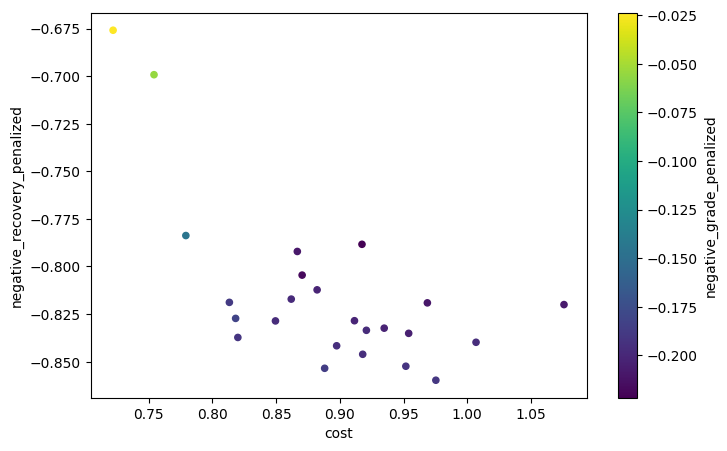

In [5]:
import pandas as pd

from mineral_process.optimization.bayesian import bayesian_optimize
from mineral_process.optimization.nsga2 import nsga2_optimize

bayesian = bayesian_optimize(state, iterations=8, initial_points=5, seed=42)
nsga2 = nsga2_optimize(state, population_size=24, generations=6, seed=42)
pareto = pd.DataFrame(
    nsga2.objectives,
    columns=["negative_recovery_penalized", "negative_grade_penalized", "cost"],
)
pareto.plot.scatter(
    x="cost",
    y="negative_recovery_penalized",
    c="negative_grade_penalized",
    colormap="viridis",
    figsize=(8, 5),
)

In [6]:
bayesian

BayesianResult(action=PlantAction(air_flow=1.3239494480239757, pulp_level=0.5255713499248671, ph=8.728979980525319, reagent_gpt=65.8911125530946, throughput_tph=169.6805646541161), objective=-125.85886980718433, evaluations=13, expected_recovery=0.8460916107937562, expected_grade=0.17106358406912098, safety_status='REVIEW')

## 4. Economic MPC prototype

In [7]:
from dataclasses import asdict

from mineral_process.control.mpc import economic_mpc

mpc = economic_mpc(state, horizon=8)
asdict(mpc)

{'action': {'air_flow': 1.3933675280218525,
  'pulp_level': 0.5471680051764654,
  'ph': 10.100014617074288,
  'reagent_gpt': 60.040356934419336,
  'throughput_tph': 175.3619731209021},
 'success': True,
 'objective': -676.6809568025371,
 'iterations': 20,
 'status': 'REVIEW',
 'predicted_recovery': 0.8870590937293541,
 'predicted_grade': 0.17436259496269454}

## Exercise

Inject a harder-ore disturbance and compare the recommended throughput before and after it. Explain
why controller output must still go through an operator/process-safety review.

In [8]:
# Answer scaffold
plant.inject_disturbance(hardness=25)
hard_state = plant.observe()
before = recommend_setpoints(state, seed=7)
after = recommend_setpoints(hard_state, seed=7)
{"before": before.to_dict(), "after": after.to_dict()}

{'before': {'action': {'air_flow': 1.442829087966235,
   'pulp_level': 0.5759954504742016,
   'ph': 10.099995184662534,
   'reagent_gpt': 80.0,
   'throughput_tph': 174.50816532191968},
  'expected_recovery': 0.9187811976398198,
  'expected_grade': 0.1764421543313377,
  'objective': -136.7676876266216,
  'safety_status': 'REVIEW',
  'reason': 'Optimization terminated successfully.'},
 'after': {'action': {'air_flow': 1.4383804860723344,
   'pulp_level': 0.6036479376311287,
   'ph': 10.064909547660974,
   'reagent_gpt': 34.3565750095557,
   'throughput_tph': 124.75102920468515},
  'expected_recovery': 0.9476614365026449,
  'expected_grade': 0.1802261294571661,
  'objective': -141.18846322928695,
  'safety_status': 'SAFE',
  'reason': 'Optimization terminated successfully.'}}

## Pitfall and extension

**Pitfall:** interpreting `SAFE` as plant safety approval; here it only means simulator constraints
were satisfied. **Extension:** compare fixed setpoints, a PID rule and MPC over the same seeded
disturbance schedule, then report recovery, grade violations and control effort.